<a href="https://colab.research.google.com/github/MMujtabaX/CV-Project/blob/main/CV_05_Multimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5: Multimodal Computer Vision — Comprehensive Lab

**Topics Covered:**
1. Image Captioning (Image → Text) with BLIP
2. Visual Question Answering (VQA)
3. Text-to-Image Generation (Stable Diffusion + SDXL Turbo)

## 0. Environment Setup

In [ ]:
# Run once to install all required packages
# Comment out after first run
# !pip install transformers diffusers accelerate --quiet

In [ ]:
import torch
import requests
import time
import os
from PIL import Image
from IPython.display import display, Image as IPyImage
from io import BytesIO

# Create output directory
os.makedirs("outputs", exist_ok=True)

# Detect device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3080
VRAM available: 10.7 GB


In [ ]:
# Helper: display multiple PIL images side by side
import matplotlib.pyplot as plt

def show_images(images, titles=None, figsize_per_image=(4, 4)):
    """Display a list of PIL images in a row."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_image[0] * n, figsize_per_image[1]))
    if n == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img)
        ax.axis("off")
        if titles:
            ax.set_title(titles[i], fontsize=10, wrap=True)
    plt.tight_layout()
    plt.show()

def load_image_from_url(url):
    """Download and return a PIL image from a URL."""
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

def save_image(image, name_prefix="output"):
    """Save a PIL image to the outputs folder with a timestamp."""
    path = f"outputs/{name_prefix}_{int(time.time())}.png"
    image.save(path)
    print(f"Saved: {path}")
    return path

---
## Section 1: Image Captioning — Image → Text

**BLIP (Bootstrapped Language-Image Pretraining)** is a vision-language model that can:
- Generate free-form captions for any image
- Answer natural language questions about an image (VQA)

Architecture: A **ViT image encoder** feeds visual tokens into a **causal language decoder**, producing text conditioned on what the model "sees".

```
  [Image] → ViT Encoder → Visual Tokens
                                ↓
                    Multimodal Fusion + LM Decoder → [Caption Text]
```

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration

print("Loading BLIP model... (downloads ~1GB on first run)")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)
print("BLIP model loaded.")

In [ ]:
def generate_caption(image, conditional_text=None, max_new_tokens=150):
    """
    Generate a caption for a PIL image.

    Args:
        image: PIL Image object
        conditional_text: Optional string to steer the caption (e.g. "a photo of")
        max_new_tokens: Maximum number of tokens to generate
    Returns:
        caption string
    """
    if conditional_text:
        inputs = blip_processor(images=image, text=conditional_text, return_tensors="pt").to(device)
    else:
        inputs = blip_processor(images=image, return_tensors="pt").to(device)

    output_ids = blip_model.generate(**inputs, max_new_tokens=max_new_tokens)
    caption = blip_processor.decode(output_ids[0], skip_special_tokens=True)
    return caption

### 1.1 Unconditional Captioning
Let the model describe the image with no hints.

In [ ]:
# Load sample images from the web
sample_images = [
    ("https://www.foundanimals.org/wp-content/uploads/2023/02/PetDates_twenty20_1d5a9cfd-bc07-4fda-9698-e39126cb25a8-1024x683.jpg", "dice"),
    ("https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=400", "dog"),
    ("https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=400", "city"),
]

images_loaded = []
for url, label in sample_images:
    try:
        img = load_image_from_url(url)
        images_loaded.append((img, label))
        print(f"Loaded: {label}")
    except Exception as e:
        print(f"Could not load {label}: {e}")

# Display them
if images_loaded:
    show_images([i[0] for i in images_loaded], titles=[i[1] for i in images_loaded])

In [ ]:
# Generate captions for all loaded images
for image, label in images_loaded:
    caption = generate_caption(image)
    print(f"[{label}] → '{caption}'")

### 1.2 Conditional Captioning
Provide a text prefix — BLIP completes it based on the image content. This forces the caption to follow a specific style or perspective.

In [ ]:
# Use the first successfully loaded image for comparison
if images_loaded:
    test_image, test_label = images_loaded[0]

    prompts = [
        None,                        # unconditioned
        "It is a fine sunny",
        "this image shows",
        "in this picture there is",
    ]

    print(f"Image: {test_label}\n")
    for prompt in prompts:
        caption = generate_caption(test_image, conditional_text=prompt)
        prefix_display = f"['{prompt}'] →" if prompt else "[No prefix] →"
        print(f"  {prefix_display} {caption}")

### 1.3 Caption Your Own Image

Upload an image file and run captioning on it.

In [ ]:
# -------------------------------------------------------
# Replace with the path to your own image file
# -------------------------------------------------------
IMAGE_PATH = "img/football.jpg"   # <-- change this

if os.path.exists(IMAGE_PATH):
    my_image = Image.open(IMAGE_PATH).convert("RGB")
    show_images([my_image], titles=["My Image"])
    print("Caption:", generate_caption(my_image))
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Upload a file or change IMAGE_PATH to an existing file path.")

---
## Section 2: Visual Question Answering (VQA)

VQA is the task of answering a natural-language question about an image. It demonstrates deep multimodal understanding — the model must ground language tokens in visual regions.

**Model:** BLIP fine-tuned for VQA (`Salesforce/blip-vqa-base`)

In [ ]:
from transformers import BlipProcessor, BlipForQuestionAnswering

print("Loading BLIP VQA model...")
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)
print("VQA model loaded.")

In [ ]:
def answer_question(image, question):
    """
    Answer a natural language question about a PIL image.
    """
    inputs = vqa_processor(images=image, text=question, return_tensors="pt").to(device)
    output_ids = vqa_model.generate(**inputs, max_new_tokens=20)
    answer = vqa_processor.decode(output_ids[0], skip_special_tokens=True)
    return answer

In [ ]:
# Run a Q&A session on a loaded image
if images_loaded:
    vqa_image, vqa_label = images_loaded[-1]  # use the last loaded image
    show_images([vqa_image], titles=[f"Image: {vqa_label}"])

    questions = [
        "What is in the image?",
        "What color is the dominant object?",
        "How many objects are visible?",
        "Is this indoors or outdoors?",
        "What time of day does it appear to be?",
    ]

    print(f"\n--- VQA Session: {vqa_label} ---")
    for q in questions:
        ans = answer_question(vqa_image, q)
        print(f"  Q: {q}")
        print(f"  A: {ans}\n")

In [ ]:
# ---------------------------------------------------------------------------
# Interactive Q&A — change the question and run this cell multiple times
# ---------------------------------------------------------------------------
if images_loaded:
    image_to_query = images_loaded[0][0]
    my_question = "What is shown in this image?"   # <-- change this

    show_images([image_to_query])
    print(f"Q: {my_question}")
    print(f"A: {answer_question(image_to_query, my_question)}")

---
## Section 3: Text-to-Image Generation

**Stable Diffusion** is a latent diffusion model that generates images from text prompts.

### How it works:
```
[Text Prompt] → CLIP Text Encoder → Conditioning Embeddings
                                             ↓
[Random Noise] → Iterative Denoising (UNet) → Latent Image → VAE Decoder → [Pixel Image]
```
- **Guidance scale** controls how strictly the output follows the prompt (higher = more faithful, less diverse)
- **Inference steps** controls quality vs. speed (more steps = better quality)
- **Seed** controls reproducibility

### 3.1 Stable Diffusion 1.5 — Workhorse Model

In [ ]:
from diffusers import StableDiffusionPipeline

print("Loading Stable Diffusion 1.5 (~4GB)...")
sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

# Enable attention slicing to reduce VRAM usage
sd_pipe.enable_attention_slicing()
print("SD 1.5 ready.")

/home/ai/miniconda3/envs/ptg/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Stable Diffusion 1.5 (~4GB)...


Loading pipeline components...:  14%|███████▌                                             | 1/7 [00:00<00:00,  7.76it/s]You are using a model of type `clip_text_model` to instantiate a model of type `clip`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.

Loading weights: 100%|██████████████████████████████████████████████████████████████| 196/196 [00:00<00:00, 2428.30it/s]
CLIPTextModel LOAD REPORT from: /home/ai/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loadin

SD 1.5 ready.


In [ ]:
def generate_sd(prompt, negative_prompt="", steps=30, guidance=7.5, seed=None, pipe=None):
    """
    Generate an image from a text prompt using Stable Diffusion.

    Args:
        prompt: What to generate
        negative_prompt: What to avoid (e.g. "blurry, low quality")
        steps: Denoising steps (20-50 typical)
        guidance: Classifier-free guidance scale (5-12 typical)
        seed: Random seed for reproducibility (None = random)
    Returns:
        PIL Image
    """
    generator = torch.Generator(device=device)
    if seed is not None:
        generator = generator.manual_seed(seed)

    active_pipe = pipe if pipe else sd_pipe
    result = active_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=steps,
        guidance_scale=guidance,
        generator=generator,
    )
    return result.images[0]

In [ ]:
# -------------------------------------------------------
# Basic generation — change prompt to experiment
# -------------------------------------------------------
# prompt = "A futuristic cityscape at sunset, ultra-realistic, 4k, dramatic lighting"
prompt = "Pakistan Army in the Field"
negative_prompt = "blurry, low quality, sketch, cartoon, watermark"

print(f"Generating: '{prompt}'")
image = generate_sd(prompt, negative_prompt=negative_prompt, seed=42)
save_image(image, "sd15_city")
show_images([image], titles=[prompt[:60] + "..."])

### 3.2 Prompt Engineering Experiment

The same concept with different prompt styles produces dramatically different outputs. Test how prompt wording affects the result.

In [ ]:
# Same subject, different artistic styles
subject = "a golden retriever sitting on a park bench"
styles = [
    "",                                   # no style
    ", oil painting, impressionist",
    ", watercolor, soft edges",
    ", photorealistic, close up",
]

generated = []
titles = []
for style in styles:
    full_prompt = subject + style
    print(f"Generating: '{full_prompt}'")
    img = generate_sd(full_prompt, seed=123, steps=25)
    generated.append(img)
    titles.append("No style" if not style else style.strip(", "))
    # save_image(img, "style_" + titles[-1][:15].replace(" ", "_"))

show_images(generated, titles=titles, figsize_per_image=(4, 4))

### 3.3 Guidance Scale Experiment

How does the `guidance_scale` parameter affect creativity vs. prompt adherence?

In [ ]:
prompt = "a golden retriever sitting in a park, photorealistic"
guidance_values = [2.0, 5.0, 7.5, 12.0, 20.0]

results = []
labels = []
for g in guidance_values:
    print(f"  guidance_scale={g}")
    img = generate_sd(prompt, guidance=g, seed=0, steps=25)
    results.append(img)
    labels.append(f"guidance={g}")

show_images(results, titles=labels)

### 3.4 SDXL Turbo — High Quality in 1-4 Steps

SDXL Turbo uses **Adversarial Diffusion Distillation (ADD)** — the model is trained to produce good outputs in just 1-4 steps instead of 50, making it ~10x faster than standard SD.

> **Note:** SDXL Turbo requires more VRAM (~8GB). If you run out of memory, skip to Section 4.

In [ ]:
from diffusers import AutoPipelineForText2Image

# Free SD 1.5 memory first if VRAM is limited
del sd_pipe
torch.cuda.empty_cache()

print("Loading SDXL Turbo (~6GB)...")
sdxl_pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    variant="fp16" if device == "cuda" else None,
).to(device)
print("SDXL Turbo ready.")

Loading SDXL Turbo (~6GB)...


/home/ai/miniconda3/envs/ptg/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...:  29%|███████████████▏                                     | 2/7 [00:00<00:00, 18.77it/s]You are using a model of type `clip_text_model` to instantiate a model of type `clip`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.

Loading weights: 100%|██████████████████████████████████████████████████████████████| 196/196 [00:00<00:00, 1893.69it/s]
You are using a model of type `clip_text_model` to instantiate a model of type `clip`. This may be

SDXL Turbo ready.


Generating: portrait of a samurai warrior, cinematic lighting,...


100%|█████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  8.66it/s]
/home/ai/miniconda3/envs/ptg/lib/python3.14/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Saved: outputs/sdxl_turbo_1773769456.png
Generating: bioluminescent ocean at night, photorealistic...


100%|█████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 14.73it/s]


Saved: outputs/sdxl_turbo_1773769456.png
Generating: a cozy cabin in a snowy forest, warm light inside,...


100%|█████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 14.92it/s]


Saved: outputs/sdxl_turbo_1773769457.png


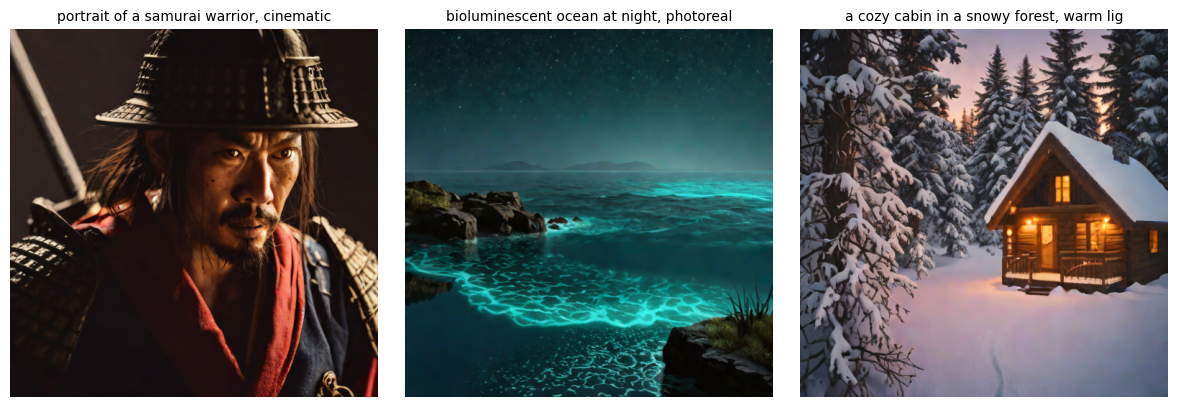

In [ ]:
# SDXL Turbo: guidance_scale=0 and num_inference_steps=1-4
# Using guidance_scale > 0 with Turbo degrades quality

prompts_sdxl = [
    "portrait of a samurai warrior, cinematic lighting, sharp focus",
    "bioluminescent ocean at night, photorealistic",
    "a cozy cabin in a snowy forest, warm light inside, dusk",
]

sdxl_results = []
for p in prompts_sdxl:
    print(f"Generating: {p[:50]}...")
    img = sdxl_pipe(
        prompt=p,
        num_inference_steps=4,
        guidance_scale=0.0,
    ).images[0]
    sdxl_results.append(img)
    save_image(img, "sdxl_turbo")

show_images(sdxl_results, titles=[p[:40] for p in prompts_sdxl])

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.68it/s]


  1 step(s) done


100%|█████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 14.47it/s]


  2 step(s) done


100%|█████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 14.51it/s]


  4 step(s) done


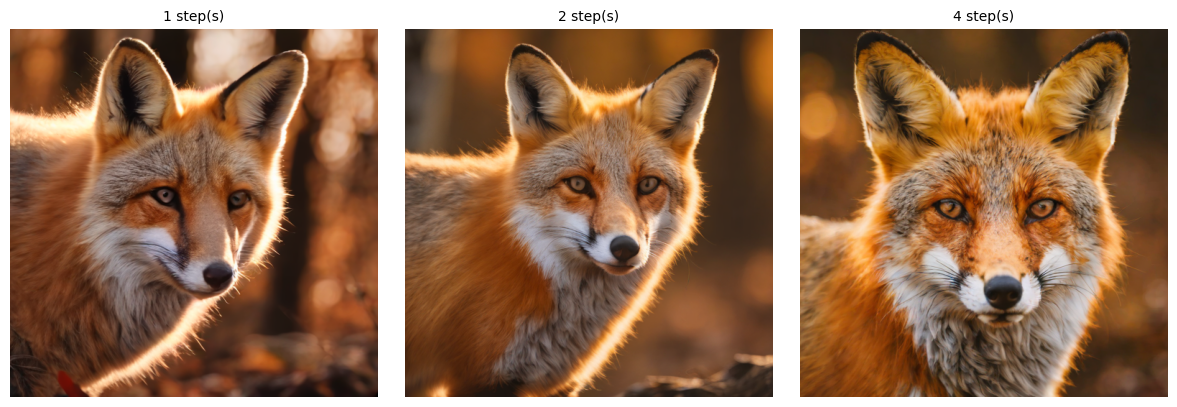

In [ ]:
# Steps comparison: 1 vs 2 vs 4 steps with SDXL Turbo
prompt = "close-up portrait of a red fox in autumn forest, golden hour"

step_images = []
step_labels = []
for n_steps in [1, 2, 4]:
    img = sdxl_pipe(prompt=prompt, num_inference_steps=n_steps, guidance_scale=0.0).images[0]
    step_images.append(img)
    step_labels.append(f"{n_steps} step(s)")
    print(f"  {n_steps} step(s) done")

show_images(step_images, titles=step_labels)

---
## Summary

| Task | Model | Input | Output |
|---|---|---|---|
| Image Captioning | BLIP | Image | Text description |
| Visual Q&A | BLIP VQA | Image + Question | Answer text |
| Text-to-Image | SD 1.5 / SDXL Turbo | Text prompt | Generated image |

### Key Takeaways
- **Multimodal models** bridge vision and language through shared embedding spaces (CLIP, ViT).
- **Diffusion models** are iterative refiners — more steps generally means better quality, but faster variants like SDXL Turbo close the gap dramatically.
- **Prompt engineering** is a skill — negative prompts, style suffixes, and conditional prefixes all significantly shape the output.